In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

ATTR_NAMES1 = [
    "sugar", "acid", "vitamin_c", "density",
    "ph", "calcium", "potassium", "magnesium",
    "fiber", "sweetness", "color",
    "score1", "score2", "score3"
]

# Different column order
ATTR_NAMES2 = [
    "ph", "fiber", "sugar", "acid",
    "color", "potassium", "vitamin_c",
    "density", "sweetness", "magnesium",
    "calcium", "score3", "score1", "score2"
]

n1 = 200
n2 = 150

data1 = np.random.uniform(0, 10, (n1, 14))
data2 = np.random.uniform(0, 10, (n2, 14))

# make scores more realistic
data1[:, -3:] = np.random.uniform(1, 9, (n1, 3))
data2[:, -3:] = np.random.uniform(1, 9, (n2, 3))

In [3]:
def array_to_csv_string(data, headers):
    rows = [";".join(headers)]

    for row in data:
        rows.append(";".join(map(str, row)))

    return "\n".join(rows)

content1 = array_to_csv_string(data1, ATTR_NAMES1)
content2 = array_to_csv_string(data2, ATTR_NAMES2)

In [4]:
lines1 = content1.strip().split("\n")
lines2 = content2.strip().split("\n")

dataset1 = np.array(
    [line.split(";") for line in lines1[1:]],
    dtype=np.float32
)

dataset2 = np.array(
    [line.split(";") for line in lines2[1:]],
    dtype=np.float32
)

print(dataset1.shape)
print(dataset2.shape)

(200, 14)
(150, 14)


In [5]:
reorder_indices = [
    ATTR_NAMES2.index(name)
    for name in ATTR_NAMES1
]

dataset2_reordered = dataset2[:, reorder_indices]

dataset = np.vstack([dataset1, dataset2_reordered])

print(dataset.shape)

(350, 14)


In [6]:
scores = dataset[:, -3:]

avg_scores = scores.mean(axis=1)
min_scores = scores.min(axis=1)

premium_mask = (avg_scores > 5) & (min_scores >= 3)
budget_mask = ~premium_mask

In [7]:
features = dataset[:, :-3]

dataset_premium = features[premium_mask]
dataset_budget = features[budget_mask]

print(dataset_premium.shape)
print(dataset_budget.shape)

(129, 11)
(221, 11)


In [8]:
np.random.shuffle(dataset_budget)
np.random.shuffle(dataset_premium)

In [9]:
def split_dataset(data):
    n = len(data)

    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    train = data[:train_end]
    val = data[train_end:val_end]
    test = data[val_end:]

    return train, val, test

In [10]:
dataset_budget_train, dataset_budget_val, dataset_budget_test = split_dataset(dataset_budget)

dataset_premium_train, dataset_premium_val, dataset_premium_test = split_dataset(dataset_premium)

In [11]:
print(dataset_budget_train.shape)
print(dataset_budget_val.shape)
print(dataset_budget_test.shape)

print(dataset_premium_train.shape)
print(dataset_premium_val.shape)
print(dataset_premium_test.shape)

(154, 11)
(33, 11)
(34, 11)
(90, 11)
(19, 11)
(20, 11)


In [12]:
def create_xy(budget, premium):

    X = np.vstack([budget, premium])

    y_budget = np.zeros((len(budget), 1))
    y_premium = np.ones((len(premium), 1))

    y = np.vstack([y_budget, y_premium])

    return X, y

In [13]:
X_train, y_train = create_xy(
    dataset_budget_train,
    dataset_premium_train
)

X_val, y_val = create_xy(
    dataset_budget_val,
    dataset_premium_val
)

X_test, y_test = create_xy(
    dataset_budget_test,
    dataset_premium_test
)

In [14]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [15]:
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

dataloader_bincl_train = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

dataloader_bincl_val = DataLoader(
    val_dataset,
    batch_size=batch_size
)

dataloader_bincl_test = DataLoader(
    test_dataset,
    batch_size=batch_size
)

In [16]:
class BinaryClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(11, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [17]:
bincl_model = BinaryClassifier()

In [18]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    bincl_model.parameters(),
    lr=0.001
)

In [19]:
best_val_loss = float("inf")
best_weights = None

patience = 10
counter = 0

train_losses = []
val_losses = []

In [20]:
epochs = 100

for epoch in range(epochs):

    # TRAIN
    bincl_model.train()

    running_train_loss = 0

    for X_batch, y_batch in dataloader_bincl_train:

        optimizer.zero_grad()

        preds = bincl_model(X_batch)

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(dataloader_bincl_train)

    # VALIDATION
    bincl_model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in dataloader_bincl_val:

            preds = bincl_model(X_batch)

            loss = criterion(preds, y_batch)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(dataloader_bincl_val)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(epoch, avg_train_loss, avg_val_loss)

    # EARLY STOPPING
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        best_weights = bincl_model.state_dict()

        counter = 0

    else:

        counter += 1

        if counter >= patience:
            print("Early stopping")
            break

0 0.673200823366642 0.7121246159076691
1 0.6733408272266388 0.7213126420974731
2 0.665971115231514 0.7168059945106506
3 0.6607589870691299 0.7126840502023697
4 0.6645265519618988 0.7131065428256989
5 0.6624437719583511 0.7140365242958069
6 0.6603803485631943 0.716134786605835
7 0.6619271114468575 0.7173999398946762
8 0.6604020595550537 0.7173613905906677
9 0.6603819280862808 0.7133575975894928
10 0.6599534302949905 0.7182854861021042
Early stopping


In [21]:
bincl_model.load_state_dict(best_weights)

<All keys matched successfully>

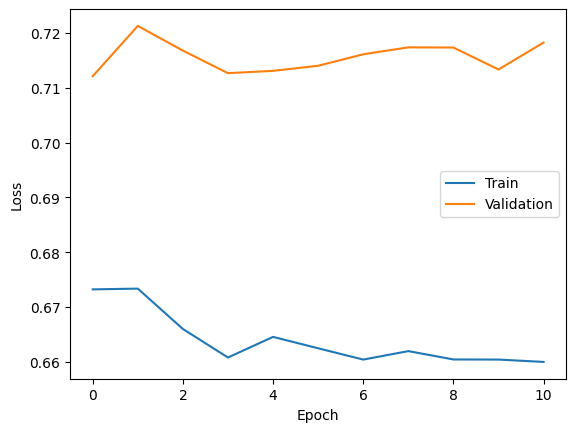

In [22]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [23]:
bincl_model.eval()

total_loss = 0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in dataloader_bincl_test:

        preds = bincl_model(X_batch)

        loss = criterion(preds, y_batch)

        total_loss += loss.item()

        predicted_labels = (preds >= 0.5).float()

        correct += (predicted_labels == y_batch).sum().item()

        total += len(y_batch)

        all_preds.append(preds)
        all_labels.append(y_batch)

In [24]:
test_bce = total_loss / len(dataloader_bincl_test)

test_acc = correct / total

print("Test BCE:", test_bce)
print("Test Accuracy:", test_acc)

Test BCE: 0.7011266052722931
Test Accuracy: 0.6296296296296297


In [25]:
for i in range(5):

    pred = predicted_labels[i].item()
    true = y_batch[i].item()

    print(f"Prediction: {pred}, true label: {true}")

Prediction: 0.0, true label: 0.0
Prediction: 0.0, true label: 0.0
Prediction: 0.0, true label: 1.0
Prediction: 0.0, true label: 1.0
Prediction: 0.0, true label: 1.0


In [26]:
all_preds = torch.cat(all_preds).numpy().flatten()
all_labels = torch.cat(all_labels).numpy().flatten()

In [27]:
budget_preds = all_preds[all_labels == 0]
premium_preds = all_preds[all_labels == 1]

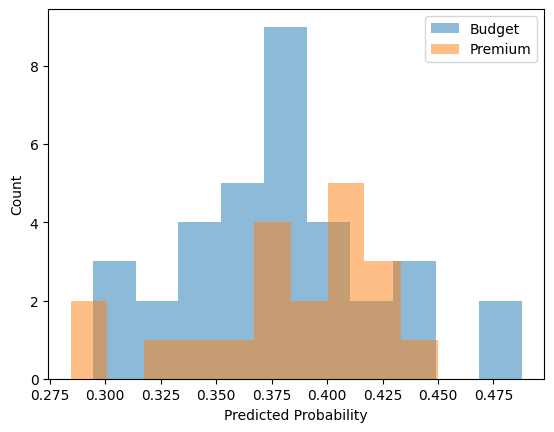

In [28]:
plt.hist(
    budget_preds,
    bins=10,
    alpha=0.5,
    label="Budget"
)

plt.hist(
    premium_preds,
    bins=10,
    alpha=0.5,
    label="Premium"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")

plt.legend()

plt.show()